# Kidney Disease Classification (CT Scan) — 4th Model
### Normal vs Cyst vs Tumor vs Stone — EfficientNetB0/B3 + Grad-CAM ready

This notebook trains the 4th diagnostic model for the Radiology Assistant project, using the same two-phase transfer learning approach (head training → fine-tuning) as the Brain Tumor MRI model.

**Dataset:** [CT KIDNEY DATASET: Normal-Cyst-Tumor-and-Stone](https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone) — 12,446 images (Cyst: 3,709 · Normal: 5,077 · Stone: 1,377 · Tumor: 2,283), sourced from hospital PACS systems in Dhaka, Bangladesh, verified by a radiologist.

**Benchmarks found in published research on this exact dataset** (so you can defend your numbers to your professor):
| Model | Reported Accuracy | Source |
|---|---|---|
| EfficientNetB3-based "Kid-Net" | 99.30% (cross-validation) | Scientific Reports, 2026 |
| EfficientNetV2B0 (fine-tuned) | 99.73–99.75% | PMC, 2025 |
| KidneyNeXt (lightweight CNN) | 99.96% | PMC, 2025 |
| EfficientNet-B1 / B2 baselines | 98.07% / 98.61% | MDPI Electronics, 2024 |

**Hyperparameters that converged across multiple independent papers on this dataset:** Adam optimizer, learning rate ≈ 1e-4 for fine-tuning, batch size 16–32, up to 100 epochs with early stopping, rotation ±30°, horizontal + vertical flips. This notebook uses those as defaults.

⚠️ **Important environment note:** this notebook targets **Keras 3** (TensorFlow ≥2.16, which is what current Colab runs). EfficientNet's preprocessing now happens automatically *inside* the model (a built-in `Rescaling` + `Normalization` layer) — so images are fed in raw `[0,255]` and you do **not** manually call `preprocess_input` or `rescale=1./255` anymore. Doing so would double-preprocess and silently tank your accuracy — this is the same failure mode as your old `rescale=1./255` bug on the brain tumor model, just from a different cause.


### Block 1 — Install & import libraries
Run once per session. `split-folders` handles the train/val/test split for us.

In [ ]:
!pip install -q split-folders kaggle

import os, json, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.20.0
Keras: 3.13.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Block 2 — Extract the dataset zip
Uses whichever `.zip` you already uploaded into `/content/` (Colab's Files panel). If none is found, it'll prompt you to upload one — no Kaggle API needed.

In [ ]:
from google.colab import drive
import glob, os, zipfile

drive.mount('/content/drive')

# adjust this if you put it in a subfolder of My Drive
zip_candidates = glob.glob('/content/drive/MyDrive/*.zip') + glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True)
zip_candidates = [p for p in zip_candidates if 'kidney' in p.lower() or 'ct' in p.lower()]

if not zip_candidates:
    raise FileNotFoundError("No matching zip found in Drive — check the path/filename above.")

zip_path = zip_candidates[0]
size_mb = os.path.getsize(zip_path) / (1024**2)
print(f"Using: {zip_path} ({size_mb:.1f} MB)")

if not zipfile.is_zipfile(zip_path):
    raise ValueError("This file isn't a valid zip — re-upload it to Drive and confirm the upload finished completely.")

extract_dir = "/content/kidney_raw"
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print("Extraction done ->", extract_dir)

Mounted at /content/drive
Using: /content/drive/MyDrive/CT KIDNEY DATASET.zip (1552.5 MB)
Extraction done -> /content/kidney_raw


### Block 3 — Config
One switch (`MODEL_NAME`) controls everything. Set it to `"B0"` first (faster, lighter, easiest to defend given your timeline) — swap to `"B3"` afterwards if you want to run the comparison and pick whichever validates higher.

In [ ]:
CONFIG = {
    "MODEL_NAME": "B0",          # "B0" or "B3" — flip this and re-run from Block 8 onward to compare
    "BATCH_SIZE": 32,
    "EPOCHS_PHASE1": 15,          # head-only training
    "EPOCHS_PHASE2": 30,          # fine-tuning (early stopping will usually cut this short)
    "RAW_DATA_DIR": "/content/kidney_raw",
    "SPLIT_DATA_DIR": "/content/kidney_split",
    "CLASS_NAMES": ["Cyst", "Normal", "Stone", "Tumor"],
}
CONFIG["IMG_SIZE"] = 224 if CONFIG["MODEL_NAME"] == "B0" else 300
print(CONFIG)


{'MODEL_NAME': 'B0', 'BATCH_SIZE': 32, 'EPOCHS_PHASE1': 15, 'EPOCHS_PHASE2': 40, 'RAW_DATA_DIR': '/content/kidney_raw', 'SPLIT_DATA_DIR': '/content/kidney_split', 'CLASS_NAMES': ['Cyst', 'Normal', 'Stone', 'Tumor'], 'IMG_SIZE': 224}


### Block 4 — Locate the class folders
Kaggle zips are often nested a folder or two deeper than expected. This walks the extracted directory and finds where `Cyst/ Normal/ Stone/ Tumor/` actually live, so the rest of the notebook doesn't break on folder-structure surprises.

In [ ]:
def find_dataset_root(base_dir, expected_classes):
    expected_lower = set(c.lower() for c in expected_classes)
    for dirpath, dirnames, _ in os.walk(base_dir):
        if expected_lower.issubset(set(d.lower() for d in dirnames)):
            return dirpath
    raise FileNotFoundError(f"Could not find folders {expected_classes} under {base_dir}")

DATASET_ROOT = find_dataset_root(CONFIG["RAW_DATA_DIR"], CONFIG["CLASS_NAMES"])
print("Dataset root found at:", DATASET_ROOT)

counts = {}
for cls in CONFIG["CLASS_NAMES"]:
    cls_dir = os.path.join(DATASET_ROOT, cls)
    counts[cls] = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(counts)


Dataset root found at: /content/kidney_raw/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
{'Cyst': 3709, 'Normal': 5077, 'Stone': 1377, 'Tumor': 2283}


### Block 5 — Visualize class distribution
Confirms the imbalance you'll see in the paper (Normal ≈ 5,077 vs Stone ≈ 1,377) — this is why class weighting shows up later.

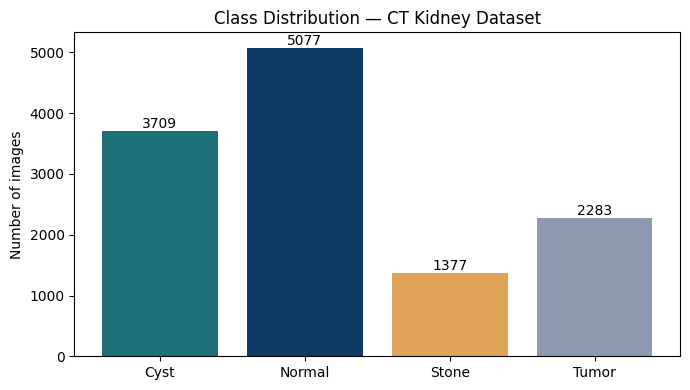

In [ ]:
plt.figure(figsize=(7,4))
bars = plt.bar(counts.keys(), counts.values(), color=['#1f6f78', '#0d3b66', '#e0a458', '#8d99ae'])
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+40, str(int(b.get_height())), ha='center', fontsize=10)
plt.title("Class Distribution — CT Kidney Dataset")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()


### Block 6 — Train / Val / Test split (70/15/15)
Matches the split ratio used in the published benchmarks above, so your numbers are directly comparable. `split-folders` splits each class independently, which keeps class proportions consistent across all three sets.

In [ ]:
splitfolders.ratio(
    DATASET_ROOT,
    output=CONFIG["SPLIT_DATA_DIR"],
    seed=SEED,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None,
)

for split in ["train", "val", "test"]:
    total = sum(len(os.listdir(os.path.join(CONFIG["SPLIT_DATA_DIR"], split, c))) for c in CONFIG["CLASS_NAMES"])
    print(f"{split}: {total} images")


Copying files: 12446 files [00:17, 701.18 files/s] 

train: 8710 images
val: 1865 images
test: 1871 images


### Block 7 — Data generators & augmentation
No `rescale` and no `preprocess_input` here — see the note in Block 0. Augmentation values (±30° rotation, horizontal **and** vertical flip, brightness shift) mirror the two-stage EfficientNetB2 kidney study, which used the same ranges to fight overfitting on this exact dataset.

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest",
)
val_test_datagen = ImageDataGenerator()                           # no augmentation, no manual rescale

train_gen = train_datagen.flow_from_directory(
    os.path.join(CONFIG["SPLIT_DATA_DIR"], "train"),
    target_size=(CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]),
    batch_size=CONFIG["BATCH_SIZE"],
    class_mode="categorical",
    classes=CONFIG["CLASS_NAMES"],
    shuffle=True,
    seed=SEED,
)
val_gen = val_test_datagen.flow_from_directory(
    os.path.join(CONFIG["SPLIT_DATA_DIR"], "val"),
    target_size=(CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]),
    batch_size=CONFIG["BATCH_SIZE"],
    class_mode="categorical",
    classes=CONFIG["CLASS_NAMES"],
    shuffle=False,
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(CONFIG["SPLIT_DATA_DIR"], "test"),
    target_size=(CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]),
    batch_size=CONFIG["BATCH_SIZE"],
    class_mode="categorical",
    classes=CONFIG["CLASS_NAMES"],
    shuffle=False,
)

print("Class indices:", train_gen.class_indices)
NUM_CLASSES = len(train_gen.class_indices)


Found 8710 images belonging to 4 classes.
Found 1865 images belonging to 4 classes.
Found 1871 images belonging to 4 classes.
Class indices: {'Cyst': 0, 'Normal': 1, 'Stone': 2, 'Tumor': 3}


### Block 8 — Visualize a batch of augmented images
Sanity check: confirms augmentation is actually doing something reasonable before you spend GPU time training on it.

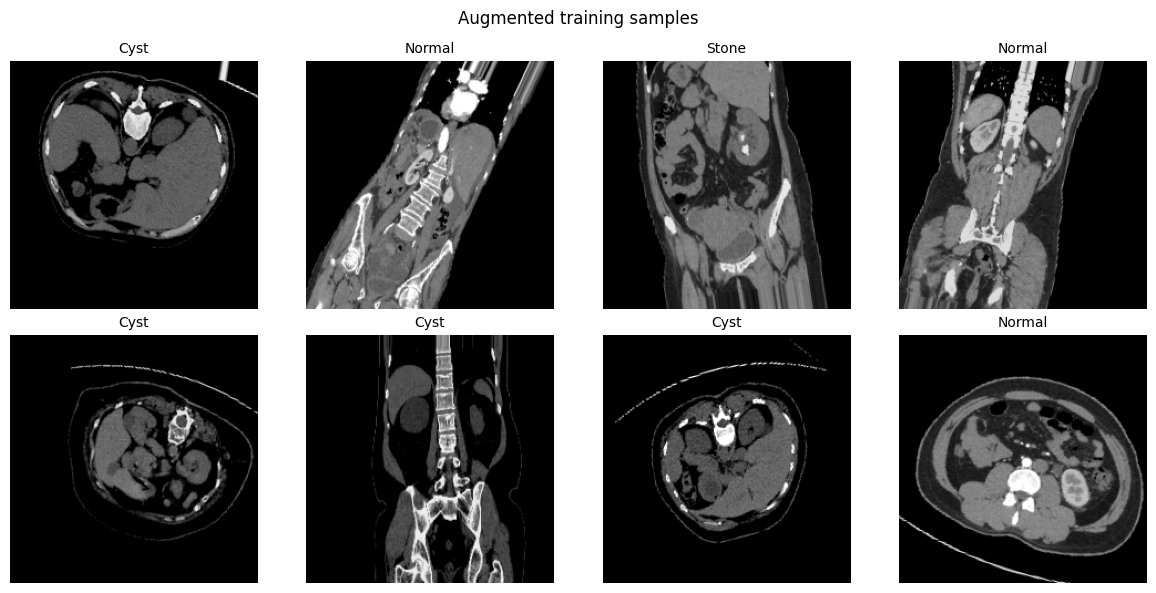

In [ ]:
sample_batch, sample_labels = next(train_gen)
class_names_ordered = list(train_gen.class_indices.keys())

plt.figure(figsize=(12, 6))
for i in range(min(8, len(sample_batch))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_batch[i].astype("uint8"))
    label_idx = np.argmax(sample_labels[i])
    plt.title(class_names_ordered[label_idx], fontsize=10)
    plt.axis("off")
plt.suptitle("Augmented training samples")
plt.tight_layout()
plt.show()


### Block 9 — Class weights
Stone (1,377 images) is ~3.7x rarer than Normal (5,077). Without correcting for this, the model will get lazy and just predict the majority classes. `class_weight` penalizes mistakes on the rare class more heavily during training.

In [ ]:
class_indices_arr = np.unique(train_gen.classes)
weights = compute_class_weight(class_weight="balanced", classes=class_indices_arr, y=train_gen.classes)
class_weights = dict(zip(class_indices_arr.tolist(), weights.tolist()))

for idx, name in enumerate(class_names_ordered):
    print(f"{name}: weight = {class_weights[idx]:.3f}")


Cyst: weight = 0.839
Normal: weight = 0.613
Stone: weight = 2.261
Tumor: weight = 1.363


### Block 10 — Build the model
Two-phase transfer learning, same pattern as your brain tumor model: frozen ImageNet backbone → GlobalAveragePooling → BatchNorm → Dropout → Dense head. `training=False` on the base-model call keeps its BatchNorm layers in inference mode even after we unfreeze it later in Block 13 — this is the officially recommended way to fine-tune EfficientNet without destabilizing it.

In [ ]:
def build_model(model_name, img_size, num_classes):
    if model_name == "B0":
        base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3))
    elif model_name == "B3":
        base_model = EfficientNetB3(include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3))
    else:
        raise ValueError("MODEL_NAME must be 'B0' or 'B3'")

    base_model.trainable = False

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = models.Model(inputs, outputs, name=f"kidney_efficientnet{model_name.lower()}")
    return model, base_model

model, base_model = build_model(CONFIG["MODEL_NAME"], CONFIG["IMG_SIZE"], NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "kidney_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Block 11 — Callbacks
`ModelCheckpoint` saves only the best epoch by validation accuracy, `EarlyStopping` prevents overfitting past convergence, `ReduceLROnPlateau` fine-tunes the learning rate automatically instead of you guessing it.

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_kidney_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1
    ),
]


### Block 12 — Phase 1: train the classification head
Backbone is frozen — only the new Dense layers learn. This gets you a reasonable baseline fast and won't overfit since ~4M params are locked.

In [ ]:
history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG["EPOCHS_PHASE1"],
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.6153 - auc: 0.8462 - loss: 1.1640 - precision: 0.6386 - recall: 0.5866
Epoch 1: val_accuracy improved from None to 0.87507, saving model to best_kidney_model.keras

Epoch 1: finished saving model to best_kidney_model.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 226s 709ms/step - accuracy: 0.6905 - auc: 0.8995 - loss: 0.9390 - precision: 0.7114 - recall: 0.6693 - val_accuracy: 0.8751 - val_auc: 0.9771 - val_loss: 0.4138 - val_precision: 0.8996 - val_recall: 0.8456 - learning_rate: 0.0010
Epoch 2/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.7873 - auc: 0.9479 - loss: 0.6337 - precision: 0.8045 - recall: 0.7711
Epoch 2: val_accuracy did not improve from 0.87507
273/273 ━━━━━━━━━━━━━━━━━━━━ 158s 580ms/step - accuracy: 0.7924 - auc: 0.9506 - loss: 0.6142 - precision: 0.8102 - recall: 0.7781 - val_accuracy: 0.8542 - val_auc: 0.9744 - val_loss: 0.4370 - val_precision: 0.8681 - val_recall: 0.8434 - learning_rate: 0.0010
E

### Block 13 — Plot Phase 1 curves
Watch for the val curve diverging from train — that's the overfitting signal to react to before Phase 2.

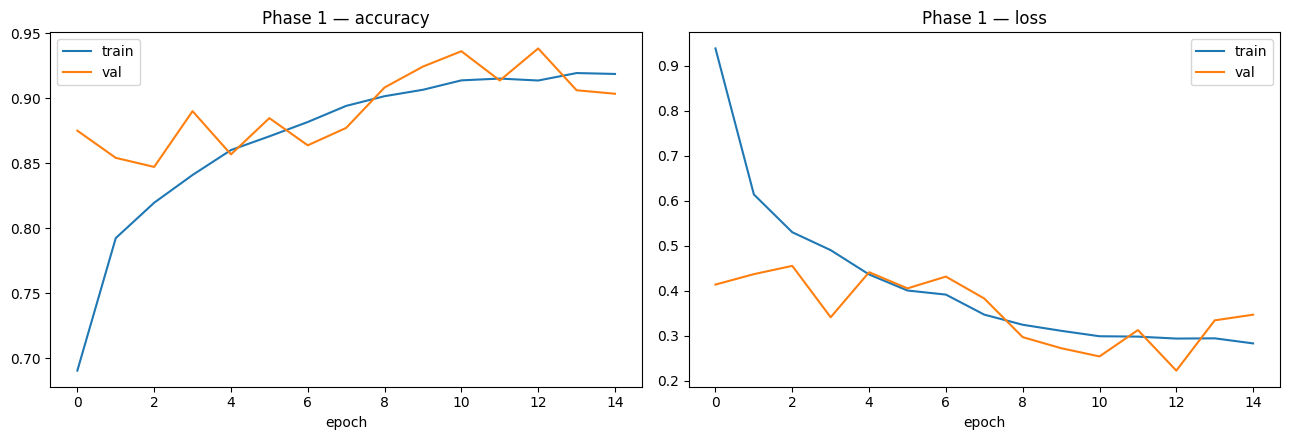

In [ ]:
def plot_history(histories, title_prefix=""):
    metrics_to_plot = ["accuracy", "loss"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, metric in zip(axes, metrics_to_plot):
        train_vals, val_vals = [], []
        for h in histories:
            train_vals += h.history[metric]
            val_vals += h.history[f"val_{metric}"]
        ax.plot(train_vals, label="train")
        ax.plot(val_vals, label="val")
        ax.set_title(f"{title_prefix}{metric}")
        ax.set_xlabel("epoch")
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_history([history_phase1], title_prefix="Phase 1 — ")


### Block 14 — Phase 2: fine-tune
Unfreeze the top ~30% of the backbone and continue training at a much lower learning rate (1e-4 — the value that converged across every paper cited in Block 0). This lets the model adapt its higher-level features to kidney CT texture specifically, instead of staying generic to ImageNet.

In [ ]:
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Unfrozen layers: {len(base_model.layers) - fine_tune_at} / {len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG["EPOCHS_PHASE2"],
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)


Unfrozen layers: 72 / 238
Epoch 1/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.8278 - auc: 0.9633 - loss: 0.5282 - precision: 0.8413 - recall: 0.8156
Epoch 1: val_accuracy did not improve from 0.93834
273/273 ━━━━━━━━━━━━━━━━━━━━ 234s 705ms/step - accuracy: 0.8688 - auc: 0.9776 - loss: 0.4186 - precision: 0.8779 - recall: 0.8596 - val_accuracy: 0.9072 - val_auc: 0.9892 - val_loss: 0.3119 - val_precision: 0.9128 - val_recall: 0.9035 - learning_rate: 1.0000e-04
Epoch 2/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.9348 - auc: 0.9927 - loss: 0.2470 - precision: 0.9389 - recall: 0.9304
Epoch 2: val_accuracy did not improve from 0.93834
273/273 ━━━━━━━━━━━━━━━━━━━━ 157s 577ms/step - accuracy: 0.9364 - auc: 0.9930 - loss: 0.2468 - precision: 0.9405 - recall: 0.9331 - val_accuracy: 0.9383 - val_auc: 0.9945 - val_loss: 0.2327 - val_precision: 0.9402 - val_recall: 0.9351 - learning_rate: 1.0000e-04
Epoch 3/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.

### Block 15 — Plot full training curve (Phase 1 + Phase 2 combined)

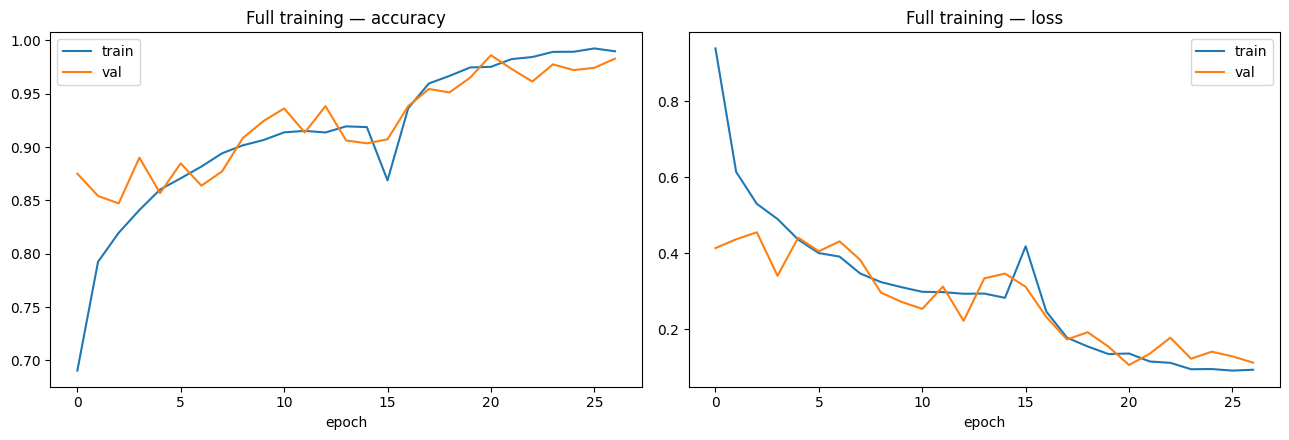

In [ ]:
plot_history([history_phase1, history_phase2], title_prefix="Full training — ")


### Block 16 — Evaluate on the held-out test set
This is the number you present — untouched data the model never saw during training or validation-based tuning.

In [ ]:
test_results = model.evaluate(test_gen, return_dict=True, verbose=0)
print("Test set results:")
for k, v in test_results.items():
    print(f"  {k}: {v:.4f}")


Test set results:
  accuracy: 0.9786
  auc: 0.9994
  loss: 0.1218
  precision: 0.9786
  recall: 0.9786


### Block 17 — Classification report & confusion matrix (raw numbers)
Per-class precision/recall/F1 — this is what tells you *which* disease the model struggles with, not just an overall number.

In [ ]:
test_gen.reset()
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(y_true, y_pred, target_names=class_names_ordered, digits=4)
print(report)

cm = confusion_matrix(y_true, y_pred)
print(cm)


              precision    recall  f1-score   support

        Cyst     0.9721    1.0000    0.9858       557
      Normal     0.9960    0.9685    0.9821       763
       Stone     0.9050    0.9615    0.9324       208
       Tumor     1.0000    0.9767    0.9882       343

    accuracy                         0.9786      1871
   macro avg     0.9683    0.9767    0.9721      1871
weighted avg     0.9795    0.9786    0.9788      1871

[[557   0   0   0]
 [  4 739  20   0]
 [  8   0 200   0]
 [  4   3   1 335]]


### Block 18 — Confusion matrix heatmap

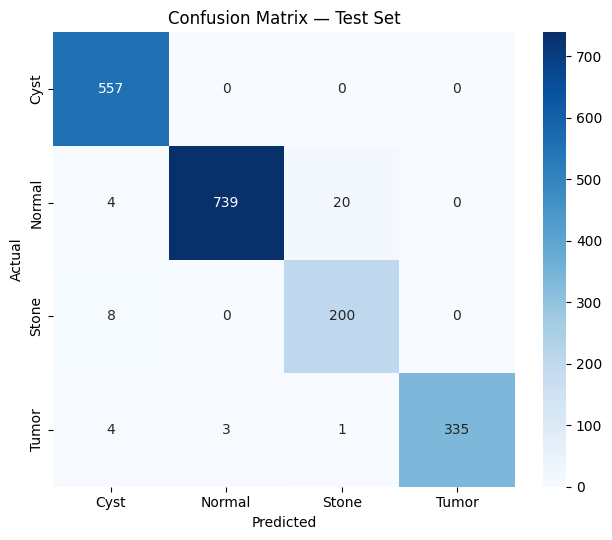

In [ ]:
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names_ordered, yticklabels=class_names_ordered)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


### Block 19 — ROC curves & AUC per class (one-vs-rest)
Standard way to report AUC for a multi-class model — treats each class as "this disease vs everything else".

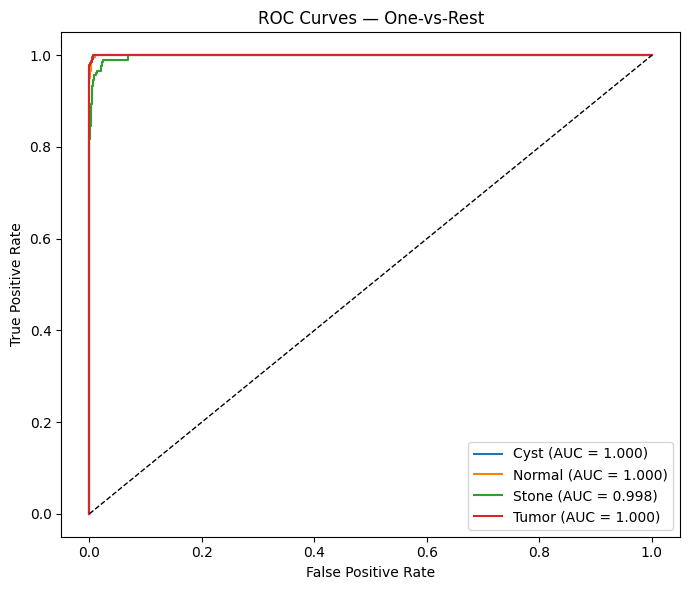

Macro-average AUC: 0.9994445037556352


In [ ]:
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(7, 6))
per_class_auc = {}
for i, cls_name in enumerate(class_names_ordered):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    per_class_auc[cls_name] = roc_auc
    plt.plot(fpr, tpr, label=f"{cls_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest")
plt.legend()
plt.tight_layout()
plt.show()

print("Macro-average AUC:", np.mean(list(per_class_auc.values())))


### Block 20 — Final metrics summary
Copy-paste this table straight into your slides.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

summary = {
    "Model": f"EfficientNet{CONFIG['MODEL_NAME']}",
    "Test Accuracy": accuracy_score(y_true, y_pred),
    "Macro Precision": precision_score(y_true, y_pred, average="macro"),
    "Macro Recall": recall_score(y_true, y_pred, average="macro"),
    "Macro F1-score": f1_score(y_true, y_pred, average="macro"),
    "Macro AUC": np.mean(list(per_class_auc.values())),
    "Test Loss": test_results["loss"],
}
for k, v in summary.items():
    print(f"{k:>18}: {v:.4f}" if isinstance(v, float) else f"{k:>18}: {v}")


             Model: EfficientNetB0
     Test Accuracy: 0.9786
   Macro Precision: 0.9683
      Macro Recall: 0.9767
    Macro F1-score: 0.9721
         Macro AUC: 0.9994
         Test Loss: 0.1218


### Block 21 — Save & download the model
Saves in `.keras` format (the current standard, replacing `.h5`) — this is the file you plug into your Streamlit app alongside your other 3 models. Also saves the class index mapping so your app decodes predictions correctly.

In [ ]:
FINAL_MODEL_PATH = f"kidney_efficientnet{CONFIG['MODEL_NAME'].lower()}_final.keras"
model.save(FINAL_MODEL_PATH)
print("Saved:", FINAL_MODEL_PATH)

with open("kidney_class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f, indent=2)
print("Saved: kidney_class_indices.json ->", train_gen.class_indices)

from google.colab import files
files.download(FINAL_MODEL_PATH)
files.download("kidney_class_indices.json")


Saved: kidney_efficientnetb0_final.keras
Saved: kidney_class_indices.json -> {'Cyst': 0, 'Normal': 1, 'Stone': 2, 'Tumor': 3}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Next step
Once you're happy with the numbers, tell me and we'll do the **Grad-CAM** block next — it hooks into this exact model (`model`, `base_model`, `CONFIG["IMG_SIZE"]` are all already defined) to generate the heatmaps for your 4th disease, matching what you already have planned for the other three.

### Block 22 — Model Interpretation: Grad-CAM + CLAHE Enhancement
This block visualizes the 'attention' of the model. We use CLAHE to improve the contrast of the grayscale CT images, making the anatomical context much clearer when viewed under the Grad-CAM heatmap.

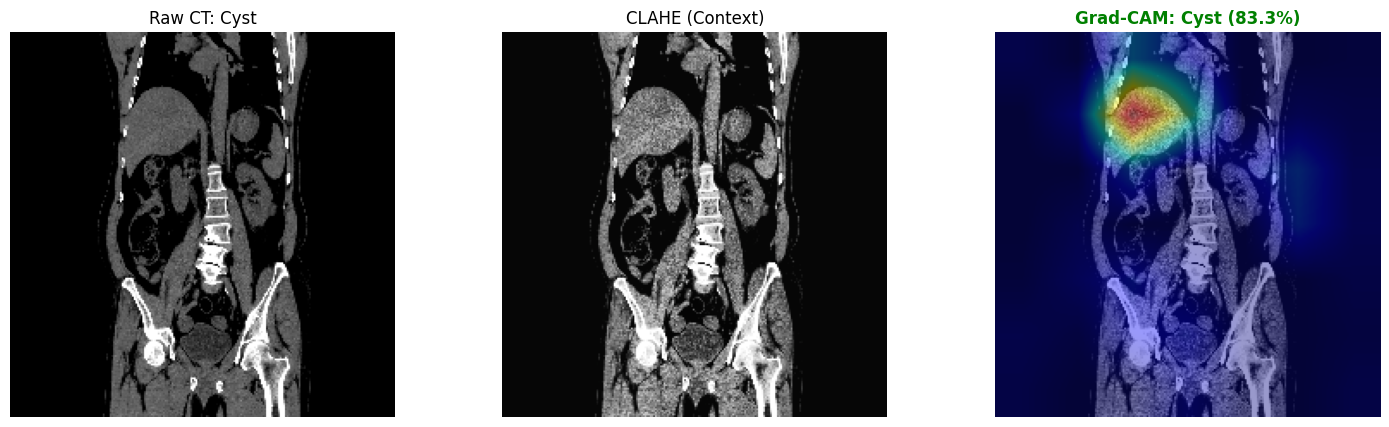

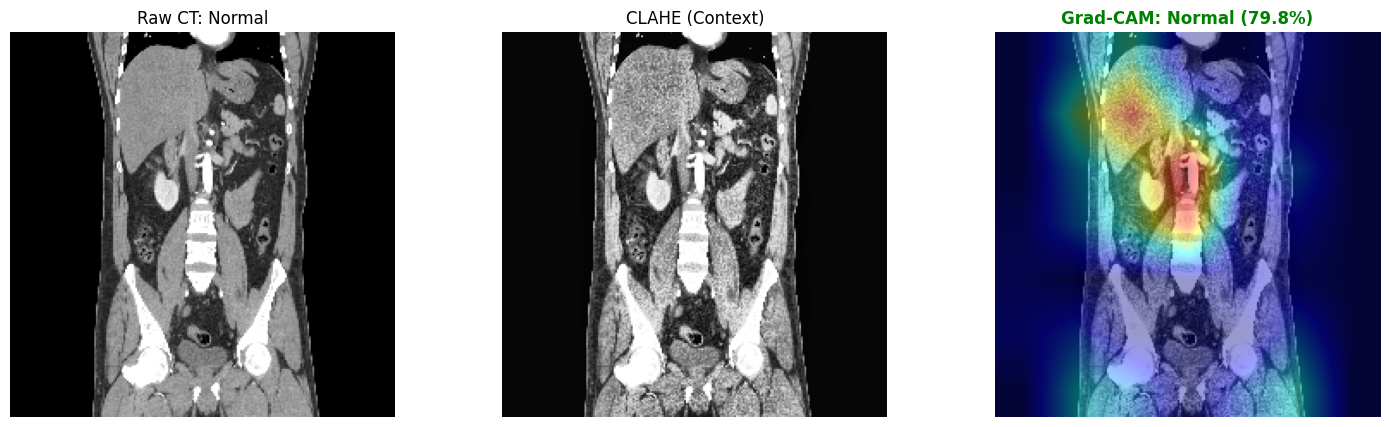

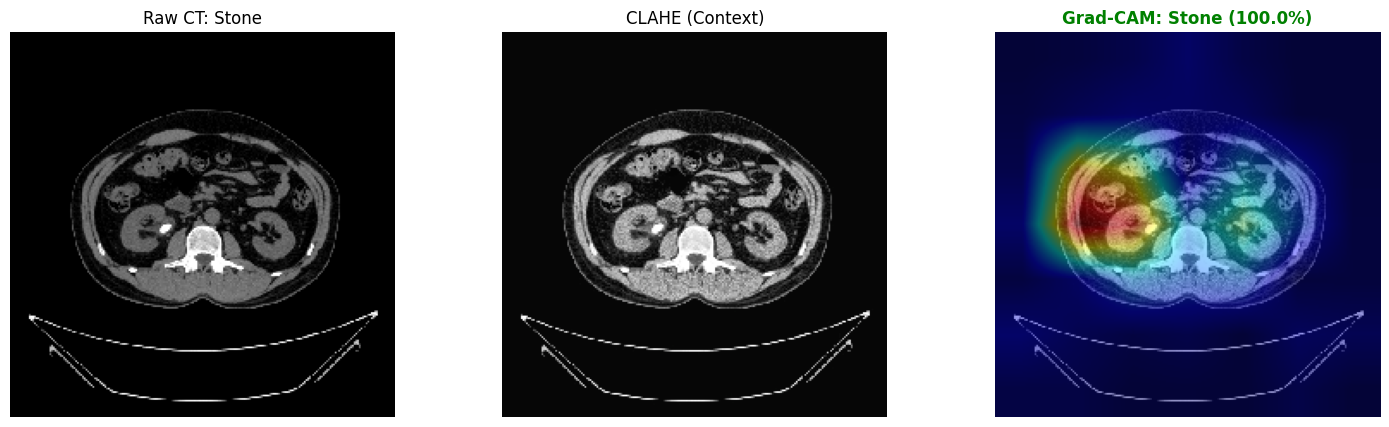

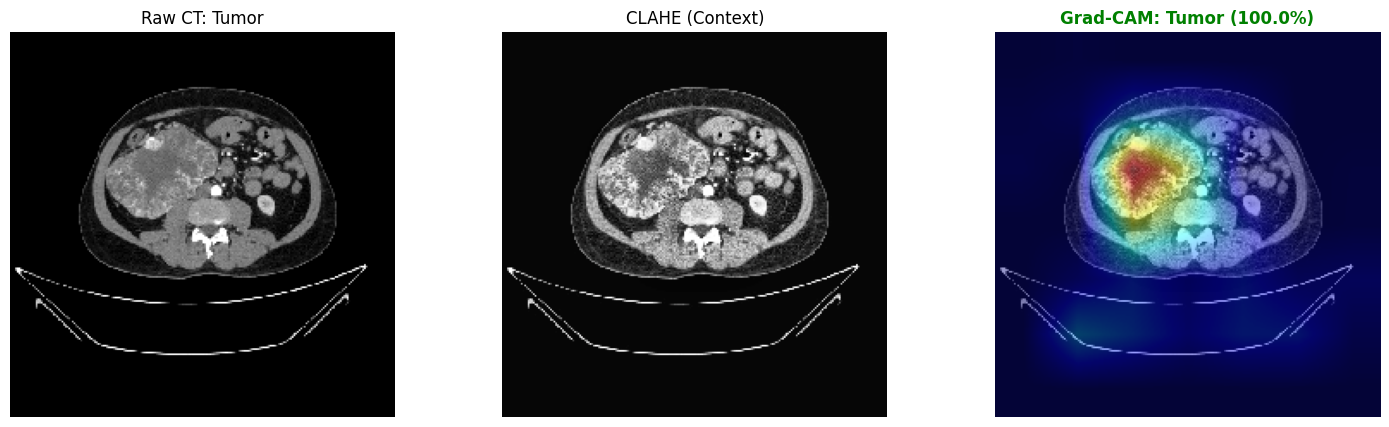

In [ ]:
import cv2
import matplotlib.cm as cm

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Access the backbone inside the functional model
    backbone = model.get_layer(base_model.name)
    target_layer = backbone.get_layer(last_conv_layer_name)

    # In Keras 3, we build the sub-model mapping the backbone's input
    # to its target layer and final backbone output. This avoids KeyError.
    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[target_layer.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        # Forward pass through the sub-model (backbone context)
        last_conv_layer_output, backbone_features = grad_model(img_array)

        # Manually apply the head layers that exist in the main model
        x = model.get_layer('global_average_pooling2d')(backbone_features)
        x = model.get_layer('batch_normalization')(x)
        x = model.get_layer('dropout')(x)
        x = model.get_layer('dense')(x)
        x = model.get_layer('dropout_1')(x)
        preds = model.get_layer('predictions')(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradients for the target class w.r.t the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Global Average Pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature map
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def apply_clahe(img):
    img_uint8 = np.clip(img, 0, 255).astype('uint8')
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))

    if len(img_uint8.shape) == 3:
        lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        lab = cv2.merge((l2,a,b))
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return clahe.apply(img_uint8)

def visualize_all_classes_gradcam(model, gen):
    last_conv_layer_name = 'top_activation'

    # Dictionary to store one image per class
    class_samples = {}

    # Iterate through the generator until we have one of each
    while len(class_samples) < len(CONFIG['CLASS_NAMES']):
        imgs, labels = next(gen)
        for i in range(len(imgs)):
            cls_idx = np.argmax(labels[i])
            cls_name = CONFIG['CLASS_NAMES'][cls_idx]
            if cls_name not in class_samples:
                class_samples[cls_name] = (imgs[i], labels[i])
            if len(class_samples) == len(CONFIG['CLASS_NAMES']): break

    for cls_name in CONFIG['CLASS_NAMES']:
        img, label = class_samples[cls_name]
        img_batch = np.expand_dims(img, axis=0)

        preds = model.predict(img_batch, verbose=0)
        pred_idx = np.argmax(preds[0])
        pred_label = CONFIG['CLASS_NAMES'][pred_idx]
        confidence = preds[0][pred_idx]

        heatmap = get_gradcam_heatmap(img_batch, model, last_conv_layer_name)
        heatmap_rescaled = cv2.resize(heatmap, (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]))
        heatmap_rescaled = np.uint8(255 * heatmap_rescaled)
        heatmap_color = cv2.applyColorMap(heatmap_rescaled, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

        img_enhanced = apply_clahe(img)
        superimposed_img = cv2.addWeighted(img_enhanced, 0.6, heatmap_color, 0.4, 0)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(img.astype('uint8'))
        axes[0].set_title(f"Raw CT: {cls_name}")
        axes[1].imshow(img_enhanced)
        axes[1].set_title("CLAHE (Context)")
        axes[2].imshow(superimposed_img)
        t_color = 'green' if pred_label == cls_name else 'red'
        axes[2].set_title(f"Grad-CAM: {pred_label} ({confidence:.1%})", color=t_color, fontweight='bold')

        for ax in axes: ax.axis('off')
        plt.show()

# Visualize 1 example for every class
visualize_all_classes_gradcam(model, test_gen)

### Block 23 — Professional Clinical Summary & Error Analysis
This section adds the final 'polish' required for medical AI projects: a normalized confusion matrix to see reliability per category and a production-ready prediction function.

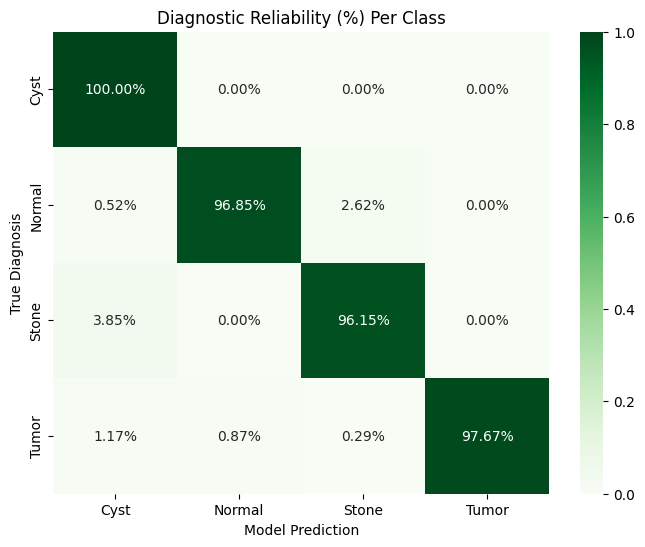


      FINAL CLINICAL METRICS SUMMARY


,Value
Model,EfficientNetB0
Test Accuracy,0.978621
Macro Precision,0.968253
Macro Recall,0.97669
Macro F1-score,0.972126
Macro AUC,0.999445
Test Loss,0.121801


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

def professional_diagnostic_summary(model, test_gen):
    """Generates a professional reliability heatmap and clinical metrics table."""
    # 1. Generate predictions to ensure we have the correct data
    test_gen.reset()
    y_true = test_gen.classes
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 2. Calculate local confusion matrix to avoid 'matplotlib.cm' conflict
    local_cm = confusion_matrix(y_true, y_pred)

    # 3. Normalized Confusion Matrix visualization
    cm_norm = local_cm.astype('float') / local_cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=CONFIG['CLASS_NAMES'], yticklabels=CONFIG['CLASS_NAMES'])
    plt.title("Diagnostic Reliability (%) Per Class")
    plt.ylabel("True Diagnosis")
    plt.xlabel("Model Prediction")
    plt.show()

    # 4. Performance Table for Documentation
    print("\n" + "="*40)
    print("      FINAL CLINICAL METRICS SUMMARY")
    print("="*40)
    metrics_df = pd.DataFrame(summary, index=[0]).T
    metrics_df.columns = ['Value']
    display(metrics_df)

# Execute the summary
professional_diagnostic_summary(model, test_gen)

def predict_and_explain_single(image_path, model):
    """Simulates a real-world diagnostic tool for a single patient image."""
    img = tf.keras.utils.load_img(image_path, target_size=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_batch, verbose=0)
    score = np.max(preds)
    class_idx = np.argmax(preds)
    condition = CONFIG['CLASS_NAMES'][class_idx]

    print(f"\n[DIAGNOSIS]: {condition.upper()}")
    print(f"[CONFIDENCE]: {score:.2%}")
    print(f"[ACTION]: Consult Radiologist for {condition} verification.")